# Fisher 矩阵预测

本教程演示 HIcosmo 的 21cm 强度映射 Fisher 预测功能。

**关键 API**：
- `list_available_surveys()` — 列出可用巡天
- `load_survey(name)` — 加载巡天配置
- `IntensityMappingFisher.forecast()` — 3 行代码完成预测
- `Plotter.from_fisher()` — 从 Fisher 结果生成 corner plot

In [1]:
import hicosmo as hc
hc.init()

INFO:hicosmo.samplers.init:Configured 8 JAX devices × 1 threads (parallel mode)
INFO:hicosmo.samplers.init:✅ HIcosmo: 8 devices ready for parallel MCMC


True

## 1. 可用巡天配置

In [2]:
from hicosmo.fisher import list_available_surveys, load_survey

# 列出所有预定义巡天
print("可用巡天:", list_available_surveys())

可用巡天: ['bingo', 'chime', 'meerkat', 'ska1', 'ska1_bull2016_exact', 'ska1_mid_band2', 'ska1_wide_band1', 'ska_mid', 'tianlai']


In [3]:
# 加载巡天配置
ska1 = load_survey('ska1_mid_band2')

print(f"巡天: {ska1.name}")
print(f"天线: {ska1.instrument.ndish} × {ska1.instrument.dish_diameter_m}m")
print(f"红移bins: {[b.z for b in ska1.redshift_bins]}")

巡天: ska1_mid_band2
天线: 133 × 15.0m
红移bins: [0.05, 0.15, 0.25, 0.35, 0.45]


## 2. 快速 Fisher 预测（3 行代码）

In [4]:
from hicosmo.fisher import IntensityMappingFisher
from hicosmo.models import LCDM

# 3 行代码完成 Fisher 预测
lcdm = LCDM(H0=67.36, Omega_m=0.3153, sigma8=0.8111)
result = IntensityMappingFisher.forecast('ska1_mid_band2', lcdm, ['H0', 'Omega_m', 'sigma8'])
print(result)

Fisher Forecast Results: ska1_mid_band2
Cosmology: LCDM
Redshift bins: 5
Parameters: H0, Omega_m, sigma8

1σ Constraints:
----------------------------------------------------------------------
  σ(H0        ) =    3.889801e+00
  σ(Omega_m   ) =    6.829627e-02
  σ(sigma8    ) =    1.062884e-01


## 3. 使用 Plotter.from_fisher 可视化

Removed no burn in


INFO:hicosmo.visualization.plotter:Corner plot saved to: /Users/qijingzhao/Programs/hicosmo_new1/tutorials/results/figures/07_fisher_corner.pdf


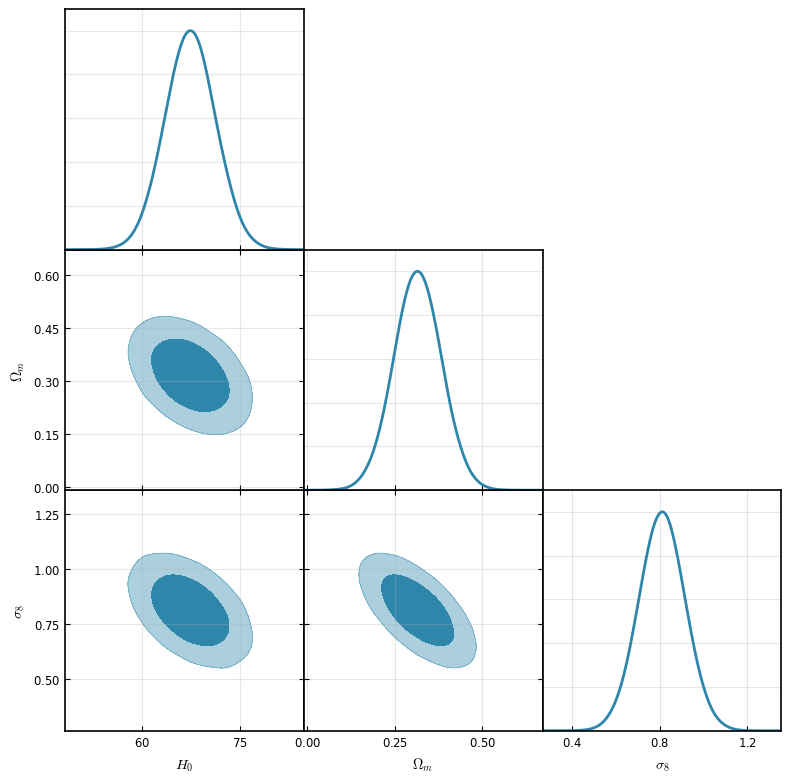

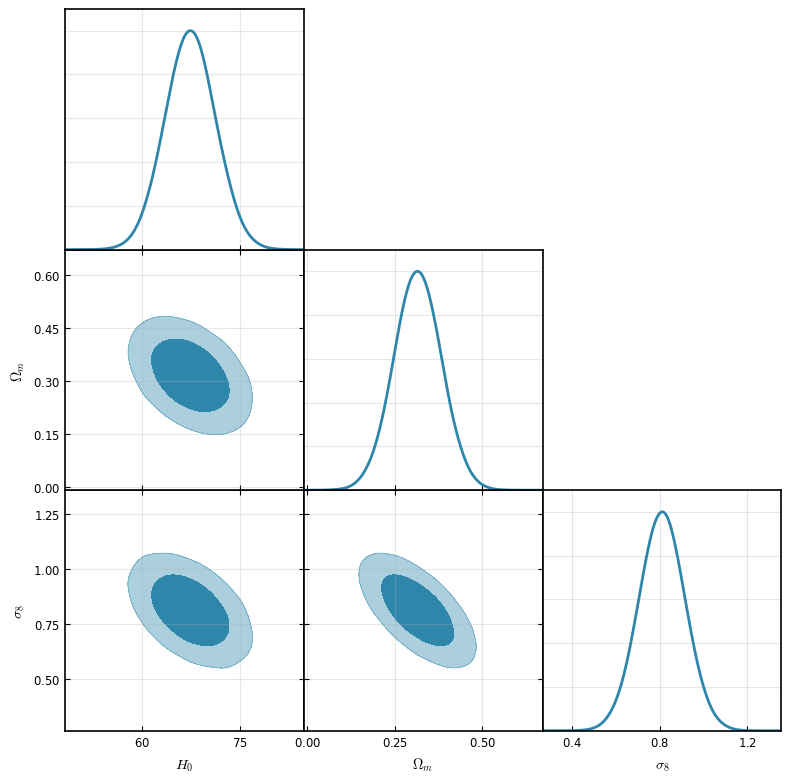

In [5]:
from hicosmo.visualization import Plotter

# 从 Fisher 结果创建 Plotter（自动使用 LaTeX 标签）
plotter = Plotter.from_fisher(
    result.get_fiducial_values(),
    result.covariance,
    result.params,
    labels=result.get_latex_labels()
)

# 生成 corner plot
plotter.corner(filename='figures/07_fisher_corner.pdf')

## 4. 暗能量模型预测（wCDM, CPL）

In [6]:
from hicosmo.models import wCDM, CPL

# wCDM 预测
wcdm = wCDM(H0=67.36, Omega_m=0.3153, w=-1.0, sigma8=0.8111)
result_w = IntensityMappingFisher.forecast('ska1_mid_band2', wcdm, ['w', 'Omega_m', 'sigma8'])
print("wCDM:")
print(result_w)

wCDM:
Fisher Forecast Results: ska1_mid_band2
Cosmology: wCDM
Redshift bins: 5
Parameters: w, Omega_m, sigma8

1σ Constraints:
----------------------------------------------------------------------
  σ(w         ) =    0.000000e+00
  σ(Omega_m   ) =    6.259768e-02
  σ(sigma8    ) =    9.476930e-02


In [7]:
# CPL 预测 (w0, wa)
cpl = CPL(H0=67.36, Omega_m=0.3153, w0=-1.0, wa=0.0, sigma8=0.8111)
result_cpl = IntensityMappingFisher.forecast('ska1_mid_band2', cpl, ['w0', 'wa', 'Omega_m'])
print("CPL:")
print(result_cpl)

CPL:
Fisher Forecast Results: ska1_mid_band2
Cosmology: CPL
Redshift bins: 5
Parameters: w0, wa, Omega_m

1σ Constraints:
----------------------------------------------------------------------
  σ(w0        ) =    6.074530e-01
  σ(wa        ) =    2.476128e+00
  σ(Omega_m   ) =    3.269536e-02


Removed no burn in


INFO:hicosmo.visualization.plotter:Corner plot saved to: /Users/qijingzhao/Programs/hicosmo_new1/tutorials/results/figures/07_cpl_corner.pdf


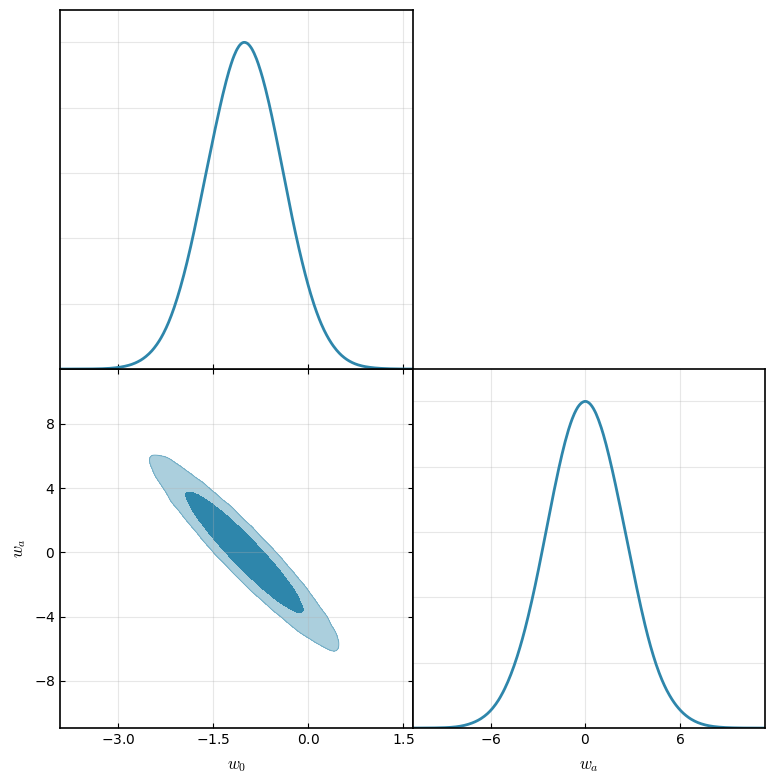

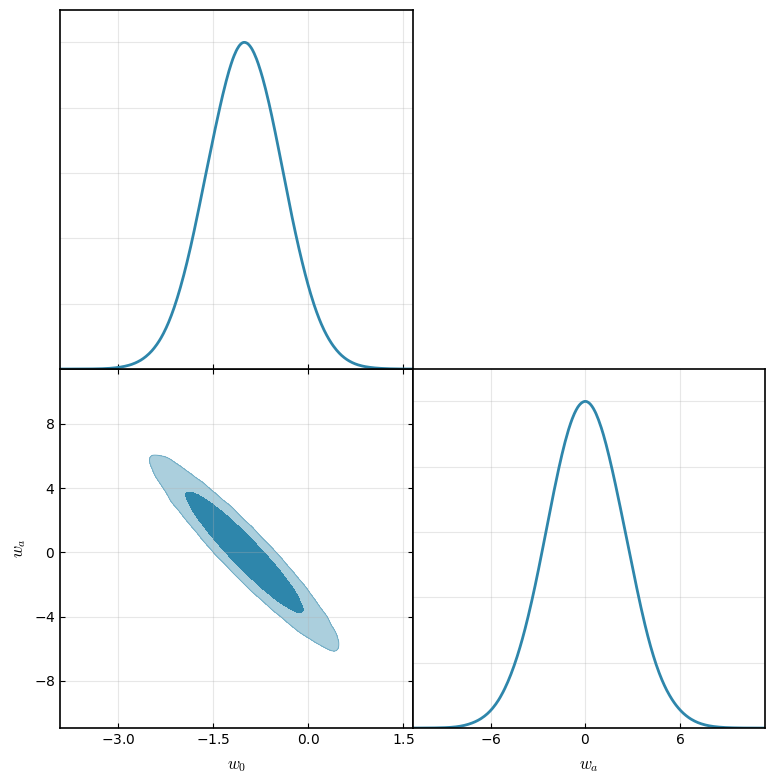

In [8]:
# CPL corner plot（使用模型中的 LaTeX 标签）
plotter_cpl = Plotter.from_fisher(
    result_cpl.get_fiducial_values(),
    result_cpl.covariance,
    result_cpl.params,
    labels=result_cpl.get_latex_labels()
)
plotter_cpl.corner(['w0', 'wa'], filename='figures/07_cpl_corner.pdf')

## 5. 多巡天比较

In [9]:
# 比较不同巡天的约束能力
surveys = ['ska1_mid_band2', 'tianlai', 'meerkat', 'bingo']
params = ['sigma8']

print(f"{'巡天':<20} {'σ(sigma8)':<15}")
print("=" * 35)

for name in surveys:
    try:
        r = IntensityMappingFisher.forecast(name, lcdm, params)
        print(f"{name:<20} {r.errors['sigma8']:<15.6f}")
    except Exception as e:
        print(f"{name:<20} Error: {e}")

巡天                   σ(sigma8)      
ska1_mid_band2       0.006444       
tianlai              0.001189       
meerkat              0.003201       
bingo                0.008508       


## 6. 实例 API（复用计算）

In [10]:
# 对同一巡天多次预测时，使用实例 API 更高效
survey = load_survey('tianlai')
fisher = IntensityMappingFisher(survey, lcdm)

# 复用 fisher 对象进行多次预测
r1 = fisher.parameter_forecast(['sigma8'])
r2 = fisher.parameter_forecast(['H0', 'sigma8'])

print(f"σ(sigma8) = {r1['errors'][0]:.4f}")
print(f"σ(H0, sigma8) = {r2['errors']}")

σ(sigma8) = 0.0012
σ(H0, sigma8) = [0.5848332  0.01265041]


## 7. 联合 Fisher 矩阵

In [11]:
import numpy as np

# Fisher 矩阵可以直接相加得到联合约束
params = ['sigma8']

F_ska = IntensityMappingFisher.forecast('ska1_mid_band2', lcdm, params).fisher_matrix
F_tianlai = IntensityMappingFisher.forecast('tianlai', lcdm, params).fisher_matrix

# 联合
F_joint = F_ska + F_tianlai
sigma_joint = 1.0 / np.sqrt(F_joint[0, 0])

print(f"SKA1 alone: σ = {1/np.sqrt(F_ska[0,0]):.5f}")
print(f"Tianlai alone: σ = {1/np.sqrt(F_tianlai[0,0]):.5f}")
print(f"Joint: σ = {sigma_joint:.5f}")

SKA1 alone: σ = 0.00644
Tianlai alone: σ = 0.00119
Joint: σ = 0.00117


## 8. 暗能量 Figure of Merit

In [12]:
def dark_energy_fom(result):
    """计算 w0-wa FoM = 1/sqrt(det(Cov))"""
    i0 = result.params.index('w0')
    i1 = result.params.index('wa')
    cov_de = result.covariance[np.ix_([i0, i1], [i0, i1])]
    return 1.0 / np.sqrt(np.linalg.det(cov_de))

# 比较不同巡天的 FoM
for name in ['ska1_mid_band2', 'tianlai']:
    r = IntensityMappingFisher.forecast(name, cpl, ['w0', 'wa', 'Omega_m'])
    print(f"{name}: FoM = {dark_energy_fom(r):.1f}")

ska1_mid_band2: FoM = 2.0
tianlai: FoM = 123.8


## API 速查

```python
from hicosmo.fisher import IntensityMappingFisher, load_survey, list_available_surveys
from hicosmo.visualization import Plotter

# 快速预测
result = IntensityMappingFisher.forecast('ska1_mid_band2', cosmology, ['H0', 'Omega_m'])

# 访问结果
result.errors              # dict: param -> sigma
result.fisher_matrix       # Fisher 矩阵
result.covariance          # 协方差矩阵
result.latex_labels        # dict: param -> LaTeX 标签
result.get_latex_labels()  # 按 params 顺序的 LaTeX 标签列表
result.get_fiducial_values()  # 按 params 顺序的基准值列表

# 可视化（自动使用模型中的 LaTeX 标签）
plotter = Plotter.from_fisher(
    result.get_fiducial_values(),
    result.covariance,
    result.params,
    labels=result.get_latex_labels()
)
plotter.corner(filename='forecast.pdf')
```